##### Feladat (Példatár 1.22)

Egy $50 ~ \mathrm{mm}$ átmérőjű kör keresztmetszetű törtvonalú tartót mutat az ábra, aminek az origóba helyezett vége be van fogva. A tartó terhelése a szabad végen működő koncentrált erő. Határozzuk meg a $B$ keresztmetszetben a csavarásból adódó csúsztatófeszültség eloszlását!

<img src="img/01.jpg" alt="Feladat" width=300px>

##### Csomagok importálása

In [1]:
import numpy as np # Numerikus számítások
import matplotlib.pyplot as plt # Ábrázolás
plt.rcParams['mathtext.fontset'] = 'cm' # Betűtípus az ábrákon
plt.rcParams['font.family'] = 'serif' # Betűtípus az ábrákon
plt.rcParams['font.serif'] = ['cmr10'] # Betűtípus az ábrákon
plt.rcParams['axes.formatter.use_mathtext'] = True # Betűtípus az ábrákon
plt.rcParams['axes.unicode_minus'] = False # Betűtípus az ábrákon
from IPython.display import display, Math, Latex # Szép kimenet Jupyter notebookban
import sympy as sp # Szimbólikus számítások
from sympy import latex # Szép kimenet Jupyter notebookban
sp.init_printing() # Szép kimenet Jupyter notebookban

##### Adatok

In [2]:
d = 50 # mm
Fx = 300 # N
Fy = 400 # N
Fz = -200 # N

F = sp.Matrix([Fx, Fy, Fz])

##### Helyvektorok

In [3]:
r_F = sp.Matrix([3, 3, -1]) # m
r_B = sp.Matrix([2, 0, 0]) # m

# B-ből F-be mutató helyvektor
r_BF = r_F - r_B
display(Math(rf'\mathbf{{r}}_{{BF}} = {latex(r_BF)} ~\mathrm{{m}}'))

<IPython.core.display.Math object>

##### Redukált nyomaték a $B$ pontba

In [4]:
M_B = r_BF.cross(F)
display(Math(rf'\mathbf{{M}}_{{B}} = {latex(M_B)} ~\mathrm{{Nm}}'))

<IPython.core.display.Math object>

In [5]:
# Ebből a csavarónyomaték az 'x' komponens
M_cs = M_B.dot(sp.Matrix([1, 0, 0]))
M_cs = M_cs * 10**3
display(Math(rf'M_{{cs}} = {latex(M_cs/1e3)} ~\mathrm{{Nm}} = {latex(M_cs)} ~\mathrm{{Nmm}}'))

<IPython.core.display.Math object>

##### Csúsztatófeszültség eloszlás

In [6]:
# Szimbólikus változó
r = sp.Symbol('r')

# Poláris másodrendű nyomaték
I_p = d**4*sp.pi/32

tau = sp.Abs(M_cs) / I_p *r
display(Math(rf'\tau (r) = {latex(tau.evalf(5))}'))

<IPython.core.display.Math object>

In [7]:
# Maximális érték a szélső szálban
tau_max = tau.subs(r, d/2)
display(Math(rf'\tau_\mathrm{{max}}  =  \tau (r=d/2) = {latex(round(tau_max, 3))} ~\mathrm{{MPa}}'))

<IPython.core.display.Math object>

##### Csúsztatófeszültség eloszlása

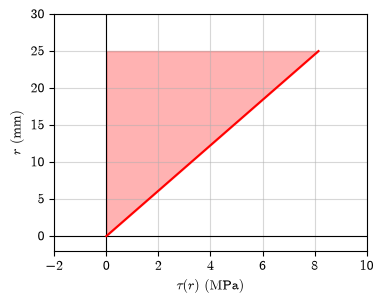

In [8]:
tau_num = sp.lambdify(r, tau)

r_vals = np.linspace(0, d/2)
tau_vals = tau_num(r_vals)

plt.figure(figsize=(10/2.54, 8/2.54))

plt.plot(tau_vals, r_vals, color='red', zorder=5)
plt.fill_betweenx(r_vals, tau_vals, 0, color='red', alpha=0.3)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel(r'$\tau (r) ~ \mathrm{(MPa)}$')
plt.ylabel(r'$r ~ \mathrm{(mm)}$')
plt.grid(True, alpha=0.5)
plt.xlim(-2, 10)
plt.ylim(-2, 30)
plt.tight_layout()
plt.savefig('csusztatofeszultseg_eloszlas.pdf')
plt.show()